# Using sign mnist dataset for this Hometask

#### Load data

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_datasets(train_name: str, test_name: str, folder_name: str):
    """ Func for get train/test sets"""

    cwd = os.getcwd()

    train_path = os.path.join(cwd, folder_name, train_name)
    test_path = os.path.join(cwd, folder_name, test_name)

    train_set = pd.read_csv(train_path)
    test_set = pd.read_csv(test_path)

    return train_set, test_set


In [10]:
train_images, test_images = get_datasets(
    train_name='sign_mnist_train.csv',
    test_name='sign_mnist_test.csv',
    folder_name='data'
)

In [11]:
train_images

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27450,13,189,189,190,190,192,193,193,193,193,...,132,165,99,77,52,200,234,200,222,225
27451,23,151,154,157,158,160,161,163,164,166,...,198,198,198,198,198,196,195,195,195,194
27452,18,174,174,174,174,174,175,175,174,173,...,121,196,209,208,206,204,203,202,200,200
27453,17,177,181,184,185,187,189,190,191,191,...,119,56,27,58,102,79,47,64,87,93


In [12]:
test_images

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,...,47,104,194,183,186,184,184,184,182,180
2,10,85,88,92,96,105,123,135,143,147,...,68,166,242,227,230,227,226,225,224,222
3,0,203,205,207,206,207,209,210,209,210,...,154,248,247,248,253,236,230,240,253,255
4,3,188,191,193,195,199,201,202,203,203,...,26,40,64,48,29,46,49,46,46,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7167,1,135,119,108,102,105,99,61,103,121,...,108,112,116,114,118,180,184,176,167,163
7168,12,157,159,161,164,166,166,171,174,175,...,213,213,213,214,213,211,210,210,209,208
7169,2,190,191,190,191,190,190,192,192,191,...,216,215,213,214,214,213,210,211,209,208
7170,4,201,205,208,209,214,216,218,223,226,...,112,169,255,255,237,113,91,67,70,63


#### Making DataLoader 

In [13]:
import torch
from torch.utils.data import(
    Dataset, 
    DataLoader
)

class CustomDataset(Dataset):
    def __init__(self, df, label_col='label', transform=None):
        self.df = df.reset_index(drop=True)
        self.label_col = label_col
        self.transform = transform
        self.pixel_cols = [c for c in df.columns if c != label_col]

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        x = self.df.loc[index, self.pixel_cols].to_numpy(dtype='float32').reshape(28, 28) / 255.0
        y = self.df.loc[index, self.label_col]
        x = torch.tensor(x).unsqueeze(0)

        if self.transform:
            x = self.transform(x)

        return x, torch.tensor(y, dtype=torch.long)
    
training_set = CustomDataset(train_images)
training_loader = DataLoader(training_set, batch_size=8, shuffle=False)

testing_set = CustomDataset(test_images)
testing_loader = DataLoader(testing_set, batch_size=8, shuffle=False)

#### Simple CNN model

In [14]:
import torch
from torch import nn
from torch import  functional as F

device = torch.device('cpu')

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 26)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

model = NeuralNetwork()
model = model.to(device)

#### Learning params

In [15]:
learning_rate = 0.01  
epochs = 10

loss_fn = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

#### Start studing and evaluating

In [16]:
from tqdm import tqdm
dict_loss = {
    'train_loss': [],
    'test_loss': [],
}
dict_accuracy = {
    'train_accuracy': [],
    'test_accuracy': []
}

def train_loop(dataloader, model, loss_fn, optimizer, epoch):
    model.train()
    total_loss, correct = 0, 0
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    tqdm_loader = tqdm(dataloader, unit='batch', desc=f'Epoch {epoch + 1}', total=len(dataloader))
    for batch, (X, y) in enumerate(tqdm_loader):
        X, y = X.to(device), y.to(device)

        pred = model(X)
        loss = loss_fn(pred, y)
        total_loss += loss.item()

        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 1000 == 0:
            tqdm_loader.set_postfix(loss=loss.item())

    correct /= size
    avg_loss = total_loss / num_batches
    dict_loss['train_loss'].append(avg_loss)
    dict_accuracy['train_accuracy'].append(correct)
    print(f"Train Error: \n Train Accuracy: {(100*correct):>0.1f}%, Avg loss: {avg_loss:>8f} \n")
        
def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    dict_loss['test_loss'].append(test_loss)
    dict_accuracy['test_accuracy'].append(correct)
    print(f"Test Error: \n Test Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

for t in range(epochs):
    train_loop(training_loader, model, loss_fn, optimizer, epoch=t)
    test_loop(testing_loader, model, loss_fn)

Epoch 1: 100%|██████████| 3432/3432 [01:27<00:00, 39.21batch/s, loss=1.78]


Train Error: 
 Train Accuracy: 19.4%, Avg loss: 2.653384 

Test Error: 
 Test Accuracy: 46.8%, Avg loss: 1.661382 



Epoch 2: 100%|██████████| 3432/3432 [01:28<00:00, 38.85batch/s, loss=1.41]


Train Error: 
 Train Accuracy: 53.8%, Avg loss: 1.363890 

Test Error: 
 Test Accuracy: 68.9%, Avg loss: 0.953506 



Epoch 3: 100%|██████████| 3432/3432 [01:27<00:00, 39.33batch/s, loss=1.03] 


...

Train Error: 
 Train Accuracy: 93.9%, Avg loss: 0.178408 

Test Error: 
 Test Accuracy: 93.3%, Avg loss: 0.264696 



Epoch 9: 100%|██████████| 3432/3432 [01:28<00:00, 38.90batch/s, loss=0.0423]


Train Error: 
 Train Accuracy: 95.2%, Avg loss: 0.143229 

Test Error: 
 Test Accuracy: 93.9%, Avg loss: 0.268584 



Epoch 10: 100%|██████████| 3432/3432 [01:28<00:00, 38.87batch/s, loss=0.0694]


Train Error: 
 Train Accuracy: 95.9%, Avg loss: 0.122828 

Test Error: 
 Test Accuracy: 92.5%, Avg loss: 0.246039 



#### Accuracy and Loss curves

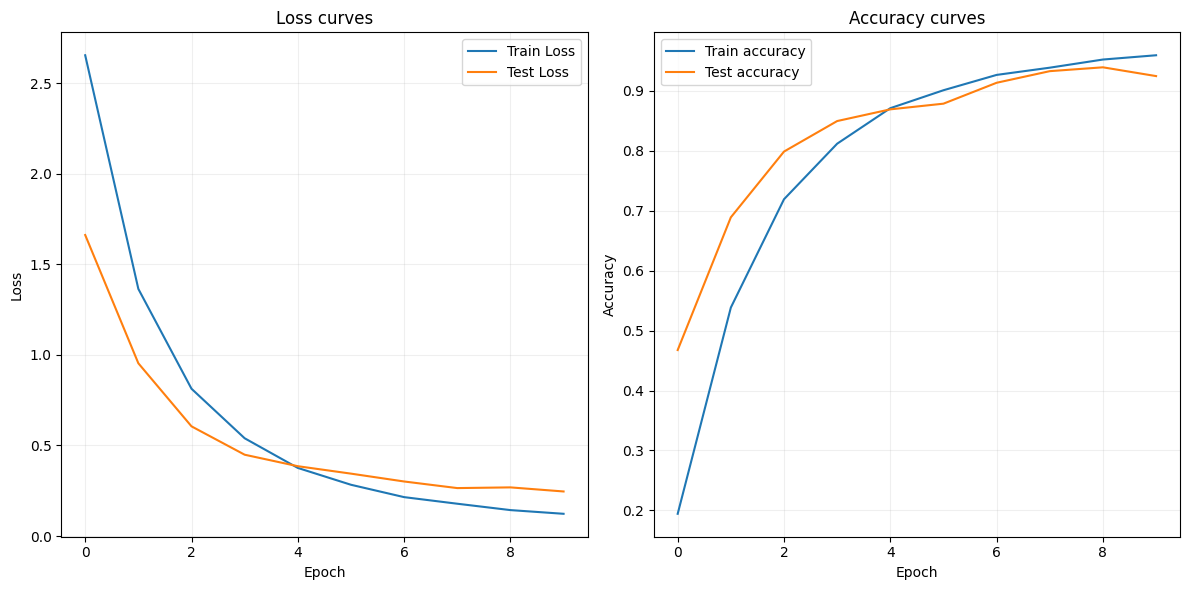

In [62]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 6))

axs[0].plot(dict_loss['train_loss'], label='Train Loss')
axs[0].plot(dict_loss['test_loss'],  label='Test Loss')
axs[0].grid(True, alpha=0.2)
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].set_title('Loss curves')
axs[0].legend()

axs[1].plot(dict_accuracy['train_accuracy'], label='Train accuracy')
axs[1].plot(dict_accuracy['test_accuracy'],  label='Test accuracy')
axs[1].grid(True, alpha=0.2)
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].set_title('Accuracy curves')
axs[1].legend()

fig.tight_layout()

#### Predict 10 Random elements from test set

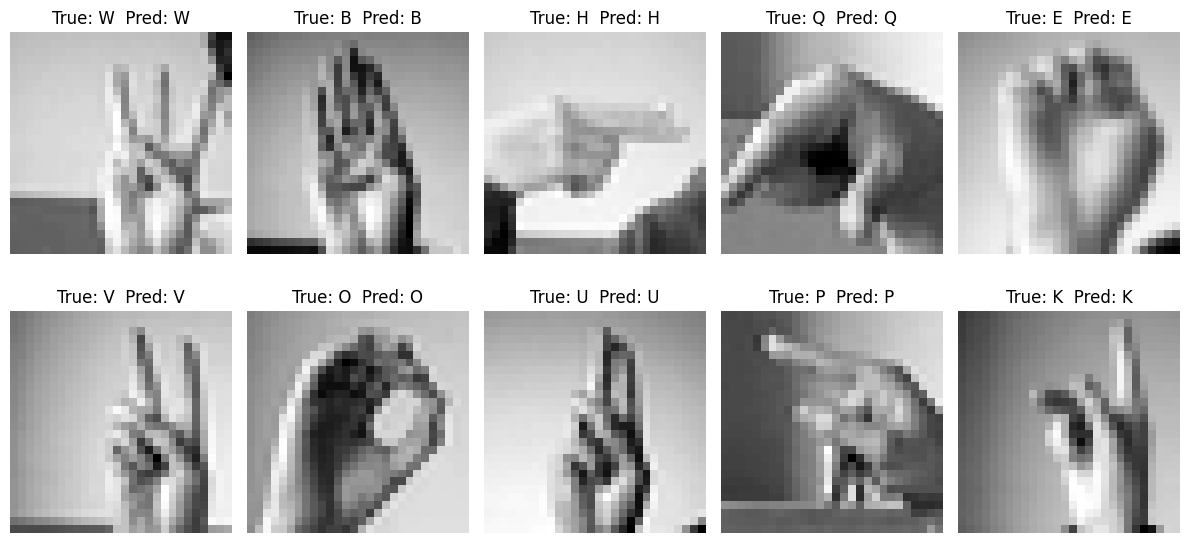

In [ ]:
label_to_char = {
    0: 'A',  1: 'B',  2: 'C',  3: 'D',  4: 'E',
    5: 'F',  6: 'G',  7: 'H',  8: 'I',  9: 'J',
    10: 'K', 11: 'L', 12: 'M', 13: 'N', 14: 'O',
    15: 'P', 16: 'Q', 17: 'R', 18: 'S', 19: 'T',
    20: 'U', 21: 'V', 22: 'W', 23: 'X', 24: 'Y', 25: 'Z'
}

model.eval()
fig, axs = plt.subplots(nrows=2, ncols=5, figsize=(12, 6))

with torch.no_grad():
    for i in range(2):
        for j in range(5):
            index = np.random.randint(0, len(testing_set))
            X, y_true = testing_set[index]

            X = X.unsqueeze(0)
            X = X.to(device)

            pred = model(X)
            y_pred = pred.argmax(dim=1).item()

            y_true_int = y_true.item()

            img = X.cpu().squeeze(0).squeeze(0)
            axs[i, j].imshow(img.numpy(), cmap='gray')
            axs[i, j].set_title(
                f"True: {label_to_char[y_true_int]}  Pred: {label_to_char[y_pred]}"
            )
            axs[i, j].axis('off')

fig.tight_layout()